# 02 Data Cleaning & Preprocessing

This notebook focuses on cleaning and preprocessing the HUPA-UCM Diabetes Dataset after the initial data understanding phase.

The goal of this notebook is to prepare the raw patient-level time-series data for exploratory data analysis and future modeling.

This notebook includes:

- loading multiple patient files
- combining patient datasets
- checking data quality
- converting timestamps
- handling missing values
- checking duplicates
- validating time-series structure
- analyzing outliers
- creating new features
- saving processed datasets

Why this step is important

This gives the notebook a clear purpose. Anyone viewing your GitHub project should immediately understand what this notebook does.

Consequence if skipped

The notebook may look unorganized, and reviewers may not understand how this notebook fits into the full project workflow.

## 1. Notebook Objective

The objective of this notebook is to clean and preprocess the raw HUPA-UCM Diabetes Dataset so that it becomes suitable for further exploratory data analysis and modeling.

The dataset contains multiple patient-level CSV files with physiological and diabetes-related measurements recorded over time.

The main variables include:

- glucose
- heart_rate
- calories
- steps
- basal_rate
- bolus_volume_delivered
- carb_input
- time

Since this is a time-series health dataset, it is important to preserve the chronological order of records for each patient.

The final output of this notebook will be:

- a cleaned combined dataset
- patient identifiers added to each record
- missing values handled
- duplicate records checked
- time-based features created
- glucose lag and rolling features created
- processed data saved for future notebooks

Why this step is important

It explains the purpose of the notebook before code begins.

Consequence if skipped

The notebook may feel like random code without a clear goa

## 2. Import Libraries

This section imports the required Python libraries for data cleaning and preprocessing.

The main libraries used are:

- pandas for data manipulation
- numpy for numerical operations
- matplotlib and seaborn for visual checks
- pathlib for handling file paths professionally

Using all imports at the beginning makes the notebook easier to read, debug, and reproduce.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use("ggplot")
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (12,6)

Why this step is important

These libraries are needed throughout the notebook for loading data, cleaning data, creating features, and saving files.

Consequence if skipped

The code will fail when functions like pd.read_csv(), np.inf, or sns.boxplot() are used.

## 3. Define Project Paths

This section defines the folder paths used in the project.

The raw data is stored in the `data/raw` folder, while the cleaned and processed datasets will be saved in the `data/processed` folder.

Using path variables makes the notebook more organized and avoids repeating long file paths multiple times.

In [71]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

Why this step is important

It keeps your project professional and reproducible.

Consequence if skipped

You may end up using hardcoded file paths, which can break when the project is moved to another computer or uploaded to GitHub.

## 4. Locate Patient Files

The HUPA-UCM Diabetes Dataset contains multiple CSV files, where each file represents data for an individual patient or related metadata.

In this step, we identify the patient-level CSV files that need to be cleaned and combined.

If the folder also contains demographic or sleep-related files, those files are excluded from the main patient time-series preprocessing workflow.

In [72]:
all_csv_files = list(RAW_DATA_DIR.glob("*.csv"))

all_csv_files

[]

In [73]:
patient_files = [
    file for file in all_csv_files
    if "demographic" not in file.name.lower()
    and "sleep" not in file.name.lower()
]

patient_files

[]

Why this step is important

You need to make sure only patient time-series files are combined.

Consequence if skipped

You may accidentally combine demographic or sleep files with patient glucose files, causing column mismatches and incorrect analysis.

## 5. Load Multiple Patient Files

Each patient file is loaded individually and assigned a `patient_id`.

The `patient_id` is created using the file name. This allows us to track which records belong to which patient after all files are combined.

This is especially important because patient-level time-series data should not be mixed during preprocessing.

In [74]:
def load_patient_file(file_path):
    df = pd.read_csv(file_path)
    df["patient_id"] = file_path.stem
    return df

In [75]:
print("Current working directory:")
print(os.getcwd())

RAW_DATA_DIR = Path("../data/raw")

print("Raw data path exists?")
print(RAW_DATA_DIR.exists())

print("Files found:")
print(list(RAW_DATA_DIR.glob("*")))

Current working directory:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\notebooks
Raw data path exists?
True
Files found:
[WindowsPath('../data/raw/HUPA-UC Diabetes Dataset')]


In [76]:
PROJECT_ROOT = Path.cwd()

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(RAW_DATA_DIR)
print(RAW_DATA_DIR.exists())
print(list(RAW_DATA_DIR.glob("*")))

c:\Projects\DataAnalysis\diabetes-glucose-analysis\notebooks\data\raw
False
[]


In [77]:
all_csv_files = list(RAW_DATA_DIR.glob("*.csv"))

all_csv_files

[]

In [78]:
patient_files = [
    file for file in all_csv_files
    if "demographic" not in file.name.lower()
    and "sleep" not in file.name.lower()
]

patient_files

[]

In [79]:
from pathlib import Path
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders in current directory:")
print(os.listdir())

print("\nFiles/folders one level up:")
print(os.listdir(".."))

Current working directory:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\notebooks

Files/folders in current directory:
['01_data_understanding.ipynb', '02_data_cleaning.ipynb', '03_exploratory_analysis.ipynb', '04_model_building.ipynb']

Files/folders one level up:
['.git', '.gitignore', 'data', 'docs', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src', 'venv', 'visuals']


In [80]:
PROJECT_ROOT = Path("c:/Projects/DataAnalysis/diabetes-glucose-analysis")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Raw data folder:")
print(RAW_DATA_DIR)

print("\nDoes raw data folder exist?")
print(RAW_DATA_DIR.exists())

print("\nAll files inside raw folder:")
for file in RAW_DATA_DIR.rglob("*"):
    print(file)

Raw data folder:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw

Does raw data folder exist?
True

All files inside raw folder:
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Dataset
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Dataset\HUPA0001P.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Dataset\HUPA0002P.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Dataset\HUPA0003P.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Dataset\HUPA0004P.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Dataset\HUPA0005P.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Dataset\HUPA0006P.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Dataset\HUPA0007P.csv
c:\Projects\DataAnalysis\diabetes-glucose-analysis\data\raw\HUPA-UC Diabetes Data

In [81]:
all_csv_files = list(RAW_DATA_DIR.rglob("*.csv"))

print("Number of CSV files found:", len(all_csv_files))

for file in all_csv_files:
    print(file.name)

Number of CSV files found: 26
HUPA0001P.csv
HUPA0002P.csv
HUPA0003P.csv
HUPA0004P.csv
HUPA0005P.csv
HUPA0006P.csv
HUPA0007P.csv
HUPA0009P.csv
HUPA0010P.csv
HUPA0011P.csv
HUPA0014P.csv
HUPA0015P.csv
HUPA0016P.csv
HUPA0017P.csv
HUPA0018P.csv
HUPA0019P.csv
HUPA0020P.csv
HUPA0021P.csv
HUPA0022P.csv
HUPA0023P.csv
HUPA0024P.csv
HUPA0025P.csv
HUPA0026P.csv
HUPA0027P.csv
HUPA0028P.csv
T1DM_patient_sleep_demographics_with_race.csv


In [82]:
patient_files = [
    file for file in all_csv_files
    if "demographic" not in file.name.lower()
    and "sleep" not in file.name.lower()
]

print("Number of patient files found:", len(patient_files))

for file in patient_files:
    print(file.name)

Number of patient files found: 25
HUPA0001P.csv
HUPA0002P.csv
HUPA0003P.csv
HUPA0004P.csv
HUPA0005P.csv
HUPA0006P.csv
HUPA0007P.csv
HUPA0009P.csv
HUPA0010P.csv
HUPA0011P.csv
HUPA0014P.csv
HUPA0015P.csv
HUPA0016P.csv
HUPA0017P.csv
HUPA0018P.csv
HUPA0019P.csv
HUPA0020P.csv
HUPA0021P.csv
HUPA0022P.csv
HUPA0023P.csv
HUPA0024P.csv
HUPA0025P.csv
HUPA0026P.csv
HUPA0027P.csv
HUPA0028P.csv


In [83]:
if len(patient_files) == 0:
    raise ValueError("No patient CSV files found. Check whether your CSV files are inside data/raw.")
else:
    patient_dfs = [load_patient_file(file) for file in patient_files]
    df_all = pd.concat(patient_dfs, ignore_index=True)
    display(df_all.head())

,time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input,patient_id
0,2018-06-13T18:40:00;332.0;6.359500050544739;82...,HUPA0001P
1,2018-06-13T18:45:00;326.0;7.72799998521805;83....,HUPA0001P
2,2018-06-13T18:50:00;330.0;4.749500036239624;80...,HUPA0001P
3,2018-06-13T18:55:00;324.0;6.359499931335449;89...,HUPA0001P
4,2018-06-13T19:00:00;306.0;5.151999890804291;92...,HUPA0001P


In [84]:
all_csv_files = list(RAW_DATA_DIR.rglob("*.csv"))

In [85]:
patient_dfs = [load_patient_file(file) for file in patient_files]

df_all = pd.concat(patient_dfs, ignore_index=True)

df_all.head()

,time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input,patient_id
0,2018-06-13T18:40:00;332.0;6.359500050544739;82...,HUPA0001P
1,2018-06-13T18:45:00;326.0;7.72799998521805;83....,HUPA0001P
2,2018-06-13T18:50:00;330.0;4.749500036239624;80...,HUPA0001P
3,2018-06-13T18:55:00;324.0;6.359499931335449;89...,HUPA0001P
4,2018-06-13T19:00:00;306.0;5.151999890804291;92...,HUPA0001P


In [86]:
if len(patient_files) == 0:
    print("No patient CSV files found. Check RAW_DATA_DIR path.")
else:
    patient_dfs = [load_patient_file(file) for file in patient_files]
    df_all = pd.concat(patient_dfs, ignore_index=True)
    display(df_all.head())

,time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input,patient_id
0,2018-06-13T18:40:00;332.0;6.359500050544739;82...,HUPA0001P
1,2018-06-13T18:45:00;326.0;7.72799998521805;83....,HUPA0001P
2,2018-06-13T18:50:00;330.0;4.749500036239624;80...,HUPA0001P
3,2018-06-13T18:55:00;324.0;6.359499931335449;89...,HUPA0001P
4,2018-06-13T19:00:00;306.0;5.151999890804291;92...,HUPA0001P


Why this step is important

It combines all patient files into one dataframe while preserving patient identity.

Consequence if skipped

You may lose track of which record belongs to which patient. This is a serious issue in healthcare and time-series analysis.

## 6. Check Combined Dataset Shape

After combining all patient files, we check the number of rows and columns in the combined dataset.

This helps confirm that the files were loaded successfully and gives an overview of the total dataset size.

In [87]:
df_all.shape

(309392, 2)

Why this step is important

It confirms that the dataset was combined properly.

Consequence if skipped

You may not notice if some files failed to load or if the combined dataset is unexpectedly small or large.

## 7. Inspect Dataset Information

This section checks column names, non-null counts, and data types.

This helps identify:

- incorrect data types
- missing values
- unexpected columns
- columns that require conversion

For this dataset, the `time` column should later be converted from object/string format to datetime format.

In [88]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 309392 entries, 0 to 309391
Data columns (total 2 columns):
 #   Column                                                                               Non-Null Count   Dtype
---  ------                                                                               --------------   -----
 0   time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input  309392 non-null  str  
 1   patient_id                                                                           309392 non-null  str  
dtypes: str(2)
memory usage: 4.7 MB


Why this step is important

It gives a quick technical overview of the dataset.

Consequence if skipped

You may perform calculations on incorrect data types, especially with timestamps.

## 8. Preview the Dataset

Previewing the first few rows helps verify that the dataset loaded correctly.

This allows us to visually inspect:

- column names
- sample values
- timestamp format
- patient identifiers
- overall structure

In [89]:
df_all.head()

,time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input,patient_id
0,2018-06-13T18:40:00;332.0;6.359500050544739;82...,HUPA0001P
1,2018-06-13T18:45:00;326.0;7.72799998521805;83....,HUPA0001P
2,2018-06-13T18:50:00;330.0;4.749500036239624;80...,HUPA0001P
3,2018-06-13T18:55:00;324.0;6.359499931335449;89...,HUPA0001P
4,2018-06-13T19:00:00;306.0;5.151999890804291;92...,HUPA0001P


In [90]:
df_all.tail()

,time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input,patient_id
309387,2022-05-18T11:55:00;109.33333333333333;10.7927...,HUPA0028P
309388,2022-05-18T12:00:00;114.0;9.803459882736206;10...,HUPA0028P
309389,2022-05-18T12:05:00;118.66666666666667;5.66621...,HUPA0028P
309390,2022-05-18T12:10:00;123.33333333333334;5.57627...,HUPA0028P
309391,2022-05-18T12:15:00;128.0;5.576279997825623;99...,HUPA0028P


Why this step is important

It helps catch obvious loading or formatting issues early.

Consequence if skipped

You may miss simple but important issues such as incorrect separators, shifted columns, or missing patient IDs.

## 9. Standardize Column Names

Column names should be consistent and easy to use in code.

This step converts column names to lowercase and removes unnecessary spaces.

Standardized column names reduce errors during analysis and make the notebook easier to maintain.

In [91]:
df_all.columns = (
    df_all.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_all.columns

Index(['time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input', 'patient_id'], dtype='str')

Why this step is important

It avoids errors caused by inconsistent column names.

Consequence if skipped

You may get errors later if column names contain spaces, capital letters, or hidden whitespace.

## 10. Convert Time Column to Datetime

The `time` column represents the timestamp of each record.

Since this is a time-series dataset, the timestamp must be converted into datetime format.

Datetime conversion allows us to:

- sort records chronologically
- extract hour, day, and date features
- calculate time intervals
- create time-based visualizations
- validate the 5-minute recording structure

In [92]:
df_all.columns

Index(['time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input', 'patient_id'], dtype='str')

In [93]:
df_all.head()

,time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input,patient_id
0,2018-06-13T18:40:00;332.0;6.359500050544739;82...,HUPA0001P
1,2018-06-13T18:45:00;326.0;7.72799998521805;83....,HUPA0001P
2,2018-06-13T18:50:00;330.0;4.749500036239624;80...,HUPA0001P
3,2018-06-13T18:55:00;324.0;6.359499931335449;89...,HUPA0001P
4,2018-06-13T19:00:00;306.0;5.151999890804291;92...,HUPA0001P


In [94]:
df_all.columns = (
    df_all.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_all.columns

Index(['time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input', 'patient_id'], dtype='str')

In [95]:
df_all.head()

,time;glucose;calories;heart_rate;steps;basal_rate;bolus_volume_delivered;carb_input,patient_id
0,2018-06-13T18:40:00;332.0;6.359500050544739;82...,HUPA0001P
1,2018-06-13T18:45:00;326.0;7.72799998521805;83....,HUPA0001P
2,2018-06-13T18:50:00;330.0;4.749500036239624;80...,HUPA0001P
3,2018-06-13T18:55:00;324.0;6.359499931335449;89...,HUPA0001P
4,2018-06-13T19:00:00;306.0;5.151999890804291;92...,HUPA0001P


In [96]:
def load_patient_file(file_path):
    df = pd.read_csv(file_path, sep=";")
    df["patient_id"] = file_path.stem
    return df

In [97]:
patient_dfs = [load_patient_file(file) for file in patient_files]

df_all = pd.concat(patient_dfs, ignore_index=True)

df_all.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id
0,2018-06-13T18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P
1,2018-06-13T18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P
2,2018-06-13T18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P
3,2018-06-13T18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P
4,2018-06-13T19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P


In [98]:
df_all.columns

Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'patient_id'],
      dtype='str')

In [99]:
df_all["time"] = pd.to_datetime(df_all["time"])

Why this step is important

Time-series analysis depends on proper datetime formatting.

Consequence if skipped

You cannot correctly calculate time differences, extract time features, or sort records chronologically.

## 11. Sort Data by Patient and Time

After converting the timestamp column, the dataset is sorted by `patient_id` and `time`.

This ensures that each patient's records are arranged in chronological order.

Sorting is required before applying time-dependent operations such as:

- forward fill
- lag features
- rolling averages
- interval checks

In [100]:
df_all = df_all.sort_values(["patient_id", "time"]).reset_index(drop=True)

df_all.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id
0,2018-06-13 18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P
1,2018-06-13 18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P
2,2018-06-13 18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P
3,2018-06-13 18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P
4,2018-06-13 19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P


Why this step is important

Time-dependent operations require correct chronological order.

Consequence if skipped

Lag features, rolling averages, and forward filling may use incorrect previous records.

## 12. Check Missing Values

Missing values are common in real-world health datasets due to sensor interruptions, device issues, or incomplete logging.

This section checks the number and percentage of missing values in each column.

Understanding missing values helps decide the correct treatment strategy for each feature.

In [101]:
missing_count = df_all.isnull().sum()
missing_count

time                      0
glucose                   0
calories                  0
heart_rate                0
steps                     0
basal_rate                0
bolus_volume_delivered    0
carb_input                0
patient_id                0
dtype: int64

In [102]:
missing_percent = df_all.isnull().mean().sort_values(ascending=False) * 100
missing_percent

time                      0.0
glucose                   0.0
calories                  0.0
heart_rate                0.0
steps                     0.0
basal_rate                0.0
bolus_volume_delivered    0.0
carb_input                0.0
patient_id                0.0
dtype: float64

Why this step is important

You need to understand the size and location of missing values before treating them.

Consequence if skipped

Missing values may cause errors in analysis, visualizations, statistics, or machine learning models.

## 13. Handle Missing Values

Different columns require different missing value strategies.

For continuous sensor-like variables such as glucose, heart rate, calories, steps, and basal rate, missing values are filled within each patient using forward fill and backward fill.

This preserves patient-level continuity without mixing data between patients.

For event-based variables such as bolus insulin delivery and carbohydrate intake, missing values are filled with 0 because missing event records usually indicate no recorded event.

In [103]:
continuous_cols = [
    "glucose",
    "heart_rate",
    "calories",
    "steps",
    "basal_rate"
]

event_cols = [
    "bolus_volume_delivered",
    "carb_input"
]

In [104]:
df_all[continuous_cols] = (
    df_all.groupby("patient_id")[continuous_cols]
    .ffill()
)

In [105]:
df_all[continuous_cols] = (
    df_all.groupby("patient_id")[continuous_cols]
    .bfill()
)

In [106]:

df_all[event_cols] = df_all[event_cols].fillna(0)

In [107]:
df_all.isnull().sum()

time                      0
glucose                   0
calories                  0
heart_rate                0
steps                     0
basal_rate                0
bolus_volume_delivered    0
carb_input                0
patient_id                0
dtype: int64

Why this step is important

It prevents missing values from interfering with future analysis.

Consequence if skipped

Missing values may distort statistics, break visualizations, and cause modeling errors.

## 14. Check Duplicate Records

Duplicate records can occur due to repeated data exports or logging errors.

This section checks for:

- fully duplicated rows
- duplicate timestamps within the same patient

Duplicate patient-time records can distort glucose trends and statistical summaries.

In [108]:
df_all.duplicated().sum()

np.int64(0)

In [109]:
duplicate_patient_times = df_all.duplicated(subset=["patient_id", "time"]).sum()

duplicate_patient_times

np.int64(0)

Why this step is important

Duplicates can bias results and overrepresent certain time points.

Consequence if skipped

Your analysis may count the same measurement more than once.

## 15. Remove Duplicate Patient-Time Records

If duplicate timestamps exist for the same patient, only the first record is kept.

This ensures that each patient has one record per timestamp.

In [110]:
df_all = df_all.drop_duplicates(subset=["patient_id", "time"], keep="first")

df_all.shape

(309392, 9)

Why this step is important

It keeps the time-series structure clean.

Consequence if skipped

Rolling averages, time intervals, and patient summaries may become inaccurate.

## 16. Validate Time-Series Interval

The patient time-series data is expected to be recorded at consistent 5-minute intervals.

This section calculates the time difference between consecutive records for each patient.

This helps confirm whether the dataset has regular temporal spacing.

In [111]:
df_all["time_diff"] = (
    df_all.groupby("patient_id")["time"]
    .diff()
)

df_all["time_diff"].value_counts().head()

time_diff
0 days 00:05:00    309367
Name: count, dtype: int64

Why this step is important

It confirms whether the time-series structure is consistent.

Consequence if skipped

You may assume the data is evenly spaced when it actually contains gaps or irregular intervals.

## 17. Identify Irregular Time Gaps

Although most records are expected to occur every 5 minutes, some patients may have missing intervals or gaps.

This section identifies records where the time difference is not equal to 5 minutes.

These gaps are important because they may affect trend analysis, rolling calculations, and future predictive modeling.

In [112]:
expected_interval = pd.Timedelta(minutes=5)

irregular_intervals = df_all[
    (df_all["time_diff"].notna()) &
    (df_all["time_diff"] != expected_interval)
]

irregular_intervals.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff


In [113]:
irregular_intervals.shape

(0, 10)

Why this step is important

It helps identify gaps in the time-series data.

Consequence if skipped

You may create misleading lag and rolling features across large time gaps.

## 18. Statistical Summary After Cleaning

After handling missing values and duplicates, summary statistics are generated again.

This helps verify the cleaned numerical values and identify unusual ranges.

The summary includes:

- count
- mean
- standard deviation
- minimum
- quartiles
- maximum

In [114]:
numeric_cols = [
    "glucose",
    "heart_rate",
    "calories",
    "steps",
    "basal_rate",
    "bolus_volume_delivered",
    "carb_input"
]

df_all[numeric_cols].describe()

,glucose,heart_rate,calories,steps,basal_rate,bolus_volume_delivered,carb_input
count,309392.000000,309392.000000,309392.000000,309392.000000,309392.000000,309392.000000,309392.000000
mean,141.425051,76.990001,8.813568,30.825005,0.041324,0.066058,0.052718
std,57.085587,15.546699,6.930449,84.981109,0.036106,0.755075,1.505433
min,40.000000,32.407773,0.000000,0.000000,0.000000,-3.000000,0.000000
25%,99.666667,64.930233,5.846100,0.000000,0.000000,0.000000,0.000000
50%,132.000000,75.418726,6.278100,0.000000,0.056000,0.000000,0.000000
75%,173.000000,85.612685,9.193060,11.000000,0.066000,0.000000,0.000000
max,444.000000,195.615385,106.350000,842.000000,0.250000,19.800000,130.000000


Why this step is important

It helps evaluate whether the cleaned data looks reasonable.

Consequence if skipped

You may miss impossible or suspicious values before moving into EDA.

## 19. Outlier Analysis

Outlier analysis is important in health datasets because extreme values may either represent:

- true medical events
- sensor errors
- data entry issues
- unusual patient behavior

For this project, outliers are analyzed but not automatically removed.

This is because extreme glucose values may be clinically meaningful and should not be removed without proper justification.

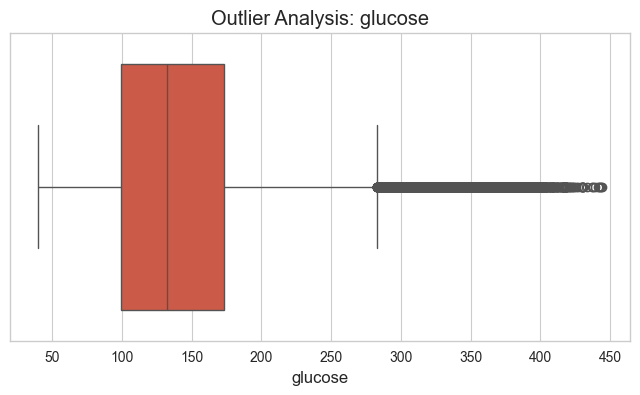

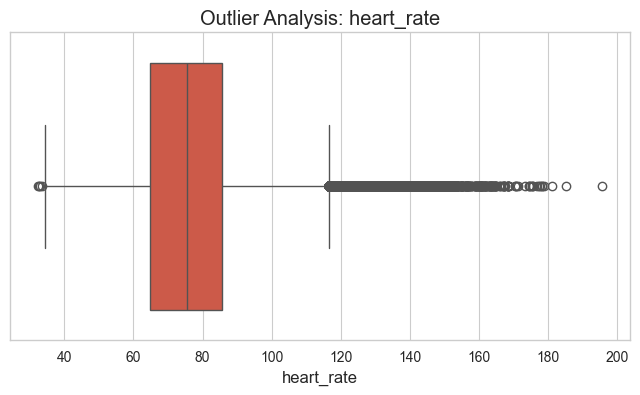

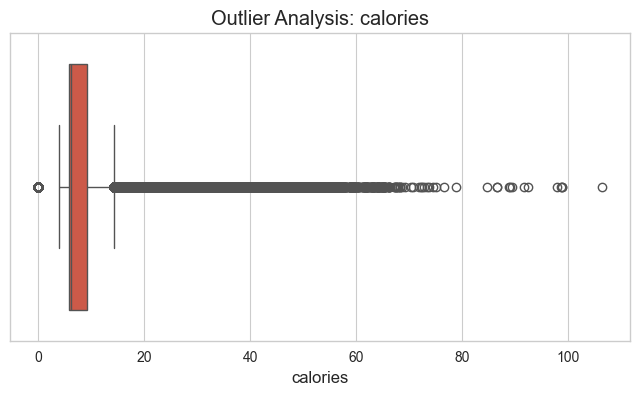

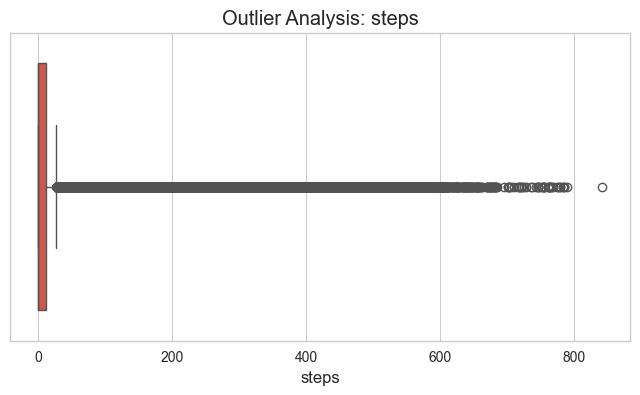

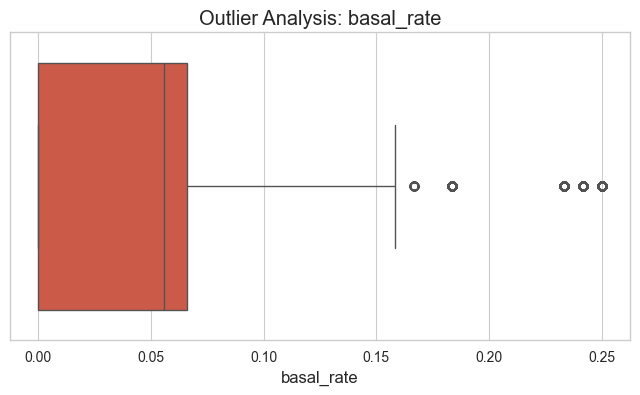

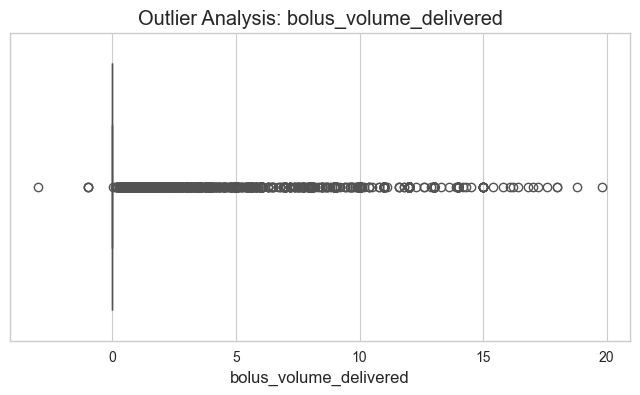

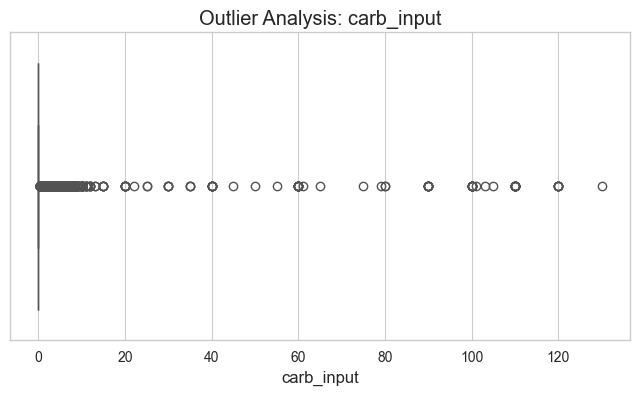

In [115]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_all[col])
    plt.title(f"Outlier Analysis: {col}")
    plt.show()

Why this step is important

It helps understand unusual values in each numerical column.

Consequence if skipped

You may overlook extreme values that could strongly influence analysis or modeling.

## 20. Create Glucose Category

Glucose values are categorized into clinically meaningful groups.

The categories used are:

- low glucose: below 70
- normal glucose: 70 to 180
- high glucose: above 180

This feature helps summarize glucose behavior and supports future analysis of hypoglycemia and hyperglycemia patterns.

In [116]:
df_all["glucose_category"] = pd.cut(
    df_all["glucose"],
    bins=[0, 70, 180, np.inf],
    labels=["low", "normal", "high"]
)

df_all["glucose_category"].value_counts()

glucose_category
normal    221170
high       67123
low        21099
Name: count, dtype: int64

Why this step is important

It converts raw glucose values into interpretable health categories.

Consequence if skipped

You may miss clinically meaningful glucose patterns.

## 21. Extract Time-Based Features

Time-based features are created from the timestamp column.

These features help analyze how glucose changes across:

- hours of the day
- days
- weekdays
- dates

Time-based features are useful because glucose levels may vary depending on daily routines, meals, sleep, activity, and insulin timing.

In [117]:
df_all["hour"] = df_all["time"].dt.hour
df_all["day"] = df_all["time"].dt.day
df_all["day_of_week"] = df_all["time"].dt.dayofweek
df_all["date"] = df_all["time"].dt.date

In [118]:
df_all[["time", "hour", "day", "day_of_week", "date"]].head()

,time,hour,day,day_of_week,date
0,2018-06-13 18:40:00,18,13,2,2018-06-13
1,2018-06-13 18:45:00,18,13,2,2018-06-13
2,2018-06-13 18:50:00,18,13,2,2018-06-13
3,2018-06-13 18:55:00,18,13,2,2018-06-13
4,2018-06-13 19:00:00,19,13,2,2018-06-13


In [119]:
df_all["time"] = pd.to_datetime(df_all["time"])

In [120]:
df_all["time"].dtype

dtype('<M8[us]')

In [121]:
df_all[["time", "hour", "day", "day_of_week", "date"]].head()

,time,hour,day,day_of_week,date
0,2018-06-13 18:40:00,18,13,2,2018-06-13
1,2018-06-13 18:45:00,18,13,2,2018-06-13
2,2018-06-13 18:50:00,18,13,2,2018-06-13
3,2018-06-13 18:55:00,18,13,2,2018-06-13
4,2018-06-13 19:00:00,19,13,2,2018-06-13


Why this step is important

It makes temporal pattern analysis easier.

Consequence if skipped

You cannot easily analyze glucose by hour, day, or weekday.

## 22. Create Time Period Feature

The hour of the day is grouped into broader time periods:

- morning
- afternoon
- evening
- night

This makes it easier to compare glucose behavior during different parts of the day.

Time period features are useful for understanding daily glucose patterns related to meals, activity, and rest.

In [122]:
def assign_time_period(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 21:
        return "evening"
    else:
        return "night"

In [123]:
df_all["time_period"] = df_all["hour"].apply(assign_time_period)

df_all["time_period"].value_counts()

time_period
night        103107
morning       89965
afternoon     64488
evening       51832
Name: count, dtype: int64

Why this step is important

It simplifies time-based analysis.

Consequence if skipped

You may need to analyze all 24 hours separately, which can be harder to interpret.

## 23. Create Glucose Lag Features

Lag features represent previous glucose values for the same patient.

Since the data is recorded every 5 minutes:

- glucose_lag_1 represents glucose from 5 minutes earlier
- glucose_lag_3 represents glucose from 15 minutes earlier
- glucose_lag_6 represents glucose from 30 minutes earlier

Lag features help capture short-term glucose history and are useful for time-series analysis and future predictive modeling.

In [124]:
df_all["glucose_lag_1"] = (
    df_all.groupby("patient_id")["glucose"]
    .shift(1)
)

df_all["glucose_lag_3"] = (
    df_all.groupby("patient_id")["glucose"]
    .shift(3)
)

df_all["glucose_lag_6"] = (
    df_all.groupby("patient_id")["glucose"]
    .shift(6)
)

In [125]:
df_all[["patient_id", "time", "glucose", "glucose_lag_1", "glucose_lag_3", "glucose_lag_6"]].head(10)

,patient_id,time,glucose,glucose_lag_1,glucose_lag_3,glucose_lag_6
0,HUPA0001P,2018-06-13 18:40:00,332.0,NaN,NaN,NaN
1,HUPA0001P,2018-06-13 18:45:00,326.0,332.0,NaN,NaN
2,HUPA0001P,2018-06-13 18:50:00,330.0,326.0,NaN,NaN
3,HUPA0001P,2018-06-13 18:55:00,324.0,330.0,332.0,NaN
4,HUPA0001P,2018-06-13 19:00:00,306.0,324.0,326.0,NaN
5,HUPA0001P,2018-06-13 19:05:00,313.0,306.0,330.0,NaN
6,HUPA0001P,2018-06-13 19:10:00,312.0,313.0,324.0,332.0
7,HUPA0001P,2018-06-13 19:15:00,293.0,312.0,306.0,326.0
8,HUPA0001P,2018-06-13 19:20:00,303.0,293.0,313.0,330.0
9,HUPA0001P,2018-06-13 19:25:00,293.0,303.0,312.0,324.0


Why this step is important

Glucose is time-dependent, so previous readings are highly useful.

Consequence if skipped

Future analysis or modeling may miss important temporal dependencies.

## 24. Create Rolling Glucose Features

Rolling features calculate the average glucose over a recent time window.

Since the data is recorded every 5 minutes:

- 6 records represent approximately 30 minutes
- 12 records represent approximately 1 hour

Rolling averages smooth short-term fluctuations and help identify broader glucose trends.

In [126]:
df_all["glucose_rolling_30min"] = (
    df_all.groupby("patient_id")["glucose"]
    .rolling(window=6, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

In [127]:
df_all["glucose_rolling_1hr"] = (
    df_all.groupby("patient_id")["glucose"]
    .rolling(window=12, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

In [128]:
df_all[[
    "patient_id",
    "time",
    "glucose",
    "glucose_rolling_30min",
    "glucose_rolling_1hr"
]].head(15)

,patient_id,time,glucose,glucose_rolling_30min,glucose_rolling_1hr
0,HUPA0001P,2018-06-13 18:40:00,332.0,332.000000,332.000000
1,HUPA0001P,2018-06-13 18:45:00,326.0,329.000000,329.000000
2,HUPA0001P,2018-06-13 18:50:00,330.0,329.333333,329.333333
3,HUPA0001P,2018-06-13 18:55:00,324.0,328.000000,328.000000
4,HUPA0001P,2018-06-13 19:00:00,306.0,323.600000,323.600000
5,HUPA0001P,2018-06-13 19:05:00,313.0,321.833333,321.833333
6,HUPA0001P,2018-06-13 19:10:00,312.0,318.500000,320.428571
7,HUPA0001P,2018-06-13 19:15:00,293.0,313.000000,317.000000
8,HUPA0001P,2018-06-13 19:20:00,303.0,308.500000,315.444444
9,HUPA0001P,2018-06-13 19:25:00,293.0,303.333333,313.200000


Why this step is important

Rolling averages help smooth noise and reveal trends.

Consequence if skipped

Analysis may focus too much on short-term fluctuations instead of meaningful patterns.

## 25. Handle Missing Values Created by Lag Features

Lag features create missing values at the beginning of each patient's time-series because earlier glucose readings do not exist.

For example, the first record for each patient will not have a previous glucose value.

Rows with missing lag values are removed to create a clean modeling-ready dataset.

In [129]:
df_all.isnull().sum()

time                        0
glucose                     0
calories                    0
heart_rate                  0
steps                       0
basal_rate                  0
bolus_volume_delivered      0
carb_input                  0
patient_id                  0
time_diff                  25
glucose_category            0
hour                        0
day                         0
day_of_week                 0
date                        0
time_period                 0
glucose_lag_1              25
glucose_lag_3              75
glucose_lag_6             150
glucose_rolling_30min       0
glucose_rolling_1hr         0
dtype: int64

In [130]:
df_clean = df_all.dropna(
    subset=[
        "glucose_lag_1",
        "glucose_lag_3",
        "glucose_lag_6"
    ]
).copy()

df_clean.shape

(309242, 21)

Why this step is important

It removes unavoidable missing values created by lag features.

Consequence if skipped

Future analysis or models may fail because of missing lag values.

## 26. Final Data Quality Check

After preprocessing and feature engineering, a final data quality check is performed.

This confirms:

- missing values have been handled
- duplicate records are removed
- data types are correct
- engineered features were created successfully
- the final dataset is ready to be saved

In [131]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 309242 entries, 6 to 309391
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype          
---  ------                  --------------   -----          
 0   time                    309242 non-null  datetime64[us] 
 1   glucose                 309242 non-null  float64        
 2   calories                309242 non-null  float64        
 3   heart_rate              309242 non-null  float64        
 4   steps                   309242 non-null  float64        
 5   basal_rate              309242 non-null  float64        
 6   bolus_volume_delivered  309242 non-null  float64        
 7   carb_input              309242 non-null  float64        
 8   patient_id              309242 non-null  str            
 9   time_diff               309242 non-null  timedelta64[us]
 10  glucose_category        309242 non-null  category       
 11  hour                    309242 non-null  int32          
 12  day                     309242 n

In [132]:
df_clean.isnull().sum()

time                      0
glucose                   0
calories                  0
heart_rate                0
steps                     0
basal_rate                0
bolus_volume_delivered    0
carb_input                0
patient_id                0
time_diff                 0
glucose_category          0
hour                      0
day                       0
day_of_week               0
date                      0
time_period               0
glucose_lag_1             0
glucose_lag_3             0
glucose_lag_6             0
glucose_rolling_30min     0
glucose_rolling_1hr       0
dtype: int64

In [133]:
df_clean.duplicated().sum()

np.int64(0)

In [134]:
df_clean.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,time_diff,glucose_category,hour,day,day_of_week,date,time_period,glucose_lag_1,glucose_lag_3,glucose_lag_6,glucose_rolling_30min,glucose_rolling_1hr
6,2018-06-13 19:10:00,312.0,10.1430,91.339623,48.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,313.0,324.0,332.0,318.500000,320.428571
7,2018-06-13 19:15:00,293.0,6.8425,89.893443,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,312.0,306.0,326.0,313.000000,317.000000
8,2018-06-13 19:20:00,303.0,5.2325,89.352941,0.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,293.0,313.0,330.0,308.500000,315.444444
9,2018-06-13 19:25:00,293.0,8.0500,89.778761,77.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,303.0,312.0,324.0,303.333333,313.200000
10,2018-06-13 19:30:00,271.0,17.7905,104.536232,124.0,0.075,0.0,0.0,HUPA0001P,0 days 00:05:00,high,19,13,2,2018-06-13,evening,293.0,293.0,306.0,297.500000,309.363636


Why this step is important

It verifies that preprocessing was successful.

Consequence if skipped

You may save a processed dataset that still contains errors.

## 27. Create Patient-Level Summary

A patient-level summary is created to understand the cleaned data at the patient level.

This summary includes:

- start time
- end time
- number of records
- average glucose
- minimum glucose
- maximum glucose

This file can be useful for reporting, patient comparison, and future exploratory analysis.

In [135]:
patient_summary = df_clean.groupby("patient_id").agg(
    start_time=("time", "min"),
    end_time=("time", "max"),
    total_records=("time", "count"),
    avg_glucose=("glucose", "mean"),
    min_glucose=("glucose", "min"),
    max_glucose=("glucose", "max")
).reset_index()

patient_summary.head()

,patient_id,start_time,end_time,total_records,avg_glucose,min_glucose,max_glucose
0,HUPA0001P,2018-06-13 19:10:00,2018-06-27 23:55:00,4090,181.237775,40.0,444.0
1,HUPA0002P,2018-06-13 23:15:00,2018-06-24 23:45:00,3175,113.534173,40.0,310.0
2,HUPA0003P,2018-06-13 22:10:00,2018-06-26 23:45:00,3764,143.285113,44.0,366.0
3,HUPA0004P,2018-07-09 16:00:00,2018-07-20 16:45:00,3178,180.379327,40.0,411.0
4,HUPA0005P,2018-07-09 14:50:00,2018-07-22 23:45:00,3852,147.628212,40.0,379.0


Why this step is important

It gives a quick overview of each patient after cleaning.

Consequence if skipped

You may not notice patient-level differences or data imbalance.

## 28. Save Processed Dataset

The cleaned dataset is saved in the `data/processed` folder.

Saving processed data is important because future notebooks can directly use this cleaned file instead of repeating all preprocessing steps.

Two files are saved:

- `diabetes_glucose_processed.csv`
- `patient_summary.csv`

In [136]:
processed_data_path = PROCESSED_DATA_DIR / "diabetes_glucose_processed.csv"
summary_data_path = PROCESSED_DATA_DIR / "patient_summary.csv"

In [137]:
df_clean.to_csv(processed_data_path, index=False)
patient_summary.to_csv(summary_data_path, index=False)

In [138]:
print(f"Processed dataset saved to: {processed_data_path}")
print(f"Patient summary saved to: {summary_data_path}")

Processed dataset saved to: ..\data\processed\diabetes_glucose_processed.csv
Patient summary saved to: ..\data\processed\patient_summary.csv


Why this step is important

It creates reusable files for the next notebooks.

Consequence if skipped

You will need to rerun the entire cleaning notebook every time you want to do analysis.

## 29. Key Findings

The data cleaning and preprocessing workflow successfully prepared the HUPA-UCM Diabetes Dataset for future analysis.

Key findings from this notebook:

- Multiple patient CSV files were loaded and combined into one dataset.
- A `patient_id` column was added to preserve patient identity.
- The `time` column was converted into datetime format.
- Records were sorted by patient and time to preserve chronological order.
- Missing values were handled based on feature type.
- Duplicate records and duplicate patient-time records were checked.
- Time-series intervals were validated to confirm 5-minute recording consistency.
- Outliers were analyzed but not automatically removed because extreme values may represent real clinical events.
- Glucose values were categorized into low, normal, and high groups.
- Time-based features were created from the timestamp.
- Lag and rolling glucose features were created to capture short-term glucose history.
- A cleaned processed dataset was saved for future notebooks.

## 30. Challenges

Several challenges were considered during preprocessing:

- The dataset contains multiple patient files, so preprocessing needed to be applied consistently across all patients.
- Patient identity had to be preserved to avoid mixing time-series records across individuals.
- Missing values required different strategies depending on whether the column represented continuous measurements or event-based records.
- Outliers could not be blindly removed because unusual glucose values may be clinically meaningful.
- Lag features introduced missing values at the beginning of each patient's sequence.
- Time-series order had to be maintained before creating lag and rolling features.

## 30. Challenges

Several challenges were considered during preprocessing:

- The dataset contains multiple patient files, so preprocessing needed to be applied consistently across all patients.
- Patient identity had to be preserved to avoid mixing time-series records across individuals.
- Missing values required different strategies depending on whether the column represented continuous measurements or event-based records.
- Outliers could not be blindly removed because unusual glucose values may be clinically meaningful.
- Lag features introduced missing values at the beginning of each patient's sequence.
- Time-series order had to be maintained before creating lag and rolling features.